# **A Web-based Tool for Automatic Discovery and Mapping of OPERA Surface Displacement (DISP-S1) product**

By using this tool, you can search, download, and map **30-meter** **[OPERA Surface Displacement (DISP-S1) products](https://www.earthdata.nasa.gov/about/nasa-support-snwg/solutions/opera-north-america-disp-product)** across North America. Derived from Sentinel-1 Interferometric Wide (IW) acquisitions from **2016-07 to Present**, these products have a 6- to 12-day revisit frequency. The interactive tool allows users to define their region of interest by uploading a boundary shapefile or drawing a polygon directly on the map.


**Reference**:
1. [Data set] NASA/JPL/OPERA. (2025). OPERA Surface Displacement from Sentinel-1 validated product (Version 1). NASA Alaska Satellite Facility Distributed Active Archive Center. https://doi.org/10.5067/SNWG/OPL3DISPS1-V1 Date Accessed: 2025-09-18

** **Note**: NASA is currently migrating all Earth science data sites to Earthdata, a process expected to continue through the end of 2026. During this transition, some NASA data and resources may not yet be accessible. This tool can automatically access new DISP-S1 products as they become available.

---


Developed by **Qianjin Zheng**, **Adnan Rajib**, and **Dipen Saha**

[Hydrology and Hydroinformatics Innovation (H2I) Lab](https://www.adnanrajib.com), University of Texas at Arlington

Please uncomment the following line each time before you run the tool for a new location (e.g., different watersheds or cities). This action will delete the entire output folder of your previous run.

## Step 1: Environment Setup

In [1]:
import sys
import os

sys.path.append(os.getcwd())

from setup_env import install_dependencies
install_dependencies()


All dependencies installed successfully.


In [2]:
import requests, folium, json, os, glob, matplotlib, gdown, gc, shutil, h5py, pyproj, textwrap, base64, warnings
import geopandas as gpd
import pandas as pd
from ipyleaflet import Map, basemaps, basemap_to_tiles, DrawControl, ImageOverlay, LayersControl
# from getpass import getpass
import getpass
from io import BytesIO
from netrc import netrc, NetrcParseError
from platform import system
from disp_xr import (download, static_layers, product, stack as disp_stack, quality_metrics, io)
from opera_utils.disp._search import search
from datetime import datetime, timezone
import xarray as xr
from pyproj import CRS, Transformer
from rasterio.crs import CRS
from pathlib import Path
from typing import Any, Dict, NamedTuple, Tuple, Union, Optional
from mintpy.utils import utils as ut
from concurrent.futures import ThreadPoolExecutor, as_completed
import rioxarray as rxr
import rasterio as rasterio
from matplotlib import cm, colorbar, ticker
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import branca.colormap as cm
from localtileserver import get_leaflet_tile_layer, TileClient
from rasterio.warp import calculate_default_transform, reproject, Resampling
# from rich import print
from rich.panel import Panel
from branca.element import Element

warnings.filterwarnings("ignore")

## Step 2: Define functions

In [3]:
def clear_m():
    global rects,polys
    rects = set()
    polys = set()

def handle_draw(self, action, geo_json):
    global rects,polys
    polygon=[]
    for coords in geo_json['geometry']['coordinates'][0][:-1][:]:
        polygon.append(tuple(coords))
    polygon = tuple(polygon)
    if geo_json['properties']['style']['color'] == '#0096FF':  # poly
        if action == 'created':
            polys.add(polygon)
        elif action == 'deleted':
            polys.discard(polygon)
    if geo_json['properties']['style']['color'] == '#0096FF':  # rect
        if action == 'created':
            rects.add(polygon)
        elif action == 'deleted':
            rects.discard(polygon)

def save_drawn_aoi(draw_control, out_dir):
  drawn_feature = draw_control.last_draw['geometry']
  if drawn_feature is not None:
    with open(out_dir+'/boundary.json', 'w') as stream:
      json.dump(draw_control.last_draw, stream, indent=2)
    gdf = gpd.read_file(out_dir+'/boundary.json')
    gdf.to_file(out_dir+'/boundary.shp')
    aoi = out_dir+'/boundary.shp'

  else: print("Please draw a Polygon feature.")
  return aoi

In [4]:
def print_boxed_message(message, title="", padding=1, bold_title=True):

    lines = message.split("\n")
    max_len = max([len(line) for line in lines] + [len(title)])
    if title:
        if bold_title:
            title_text = f"\033[1;31m{title}\033[0m"
        else:
            title_text = title
        max_len = max(max_len, len(title))

    if title:
        print(title_text.ljust(max_len))
    print("*" * (max_len + 4))
    for _ in range(padding):
        print("*" + " " * (max_len + 2) + "*")
    for line in lines:
        print("* " + line.ljust(max_len) + " *")
    for _ in range(padding):
        print("*" + " " * (max_len + 2) + "*")
    print("*" * (max_len + 4))

In [5]:
def decode_metadata_time(v):
    if isinstance(v, (np.ndarray, bytes)):
        return b"".join(v).decode("utf-8") if isinstance(v[0], (bytes, np.bytes_)) else str(v)
    return str(v)

def extract_pixel_bbox_from_lalo(coord, lonlat_bbox):
    min_lon,  max_lon, min_lat, max_lat = lonlat_bbox.values()
    y0, x0 = coord.lalo2yx(min_lat, min_lon)
    y1, x1 = coord.lalo2yx(max_lat, max_lon)
    return slice(int(min(y0, y1)), int(max(y0, y1))), slice(int(min(x0, x1)), int(max(x0, x1)))

def get_metadata(disp_nc: str | Path | BytesIO| h5py.File, reference_date: Optional[str] = None) -> dict:
    """Get metadata for MINTPY from a DISP NetCDF file.

    Args:
        disp_nc (str or Path): The path to the DISP NetCDF file.
        reference_date (str, optional): The reference date. Defaults to None.

    Returns:
        dict: A dictionary containing the metadata.

    """
    # Get high-level metadata from DISP
    is_open_file = isinstance(disp_nc, h5py.File)
    if is_open_file:
        ds = disp_nc
    else:
        ds = h5py.File(disp_nc, "r")
    length, width = ds["displacement"][:].shape

    # Get general metadata
    metadata = {}
    for key, value in ds.attrs.items():
        metadata[key] = value

    for key, value in ds["identification"].items():
        value = value[()]
        if isinstance(value, (bytes, bytearray)):
            value = value.decode("utf-8")
        metadata[key] = value

    for key, value in ds["metadata"].items():
        # Skip unnecessary keys
        if key not in ["reference_orbit", "secondary_orbit", "processing_information"]:
            metadata[key] = value[()]

    metadata["x"] = ds["x"][:]
    metadata["y"] = ds["y"][:]
    metadata["length"] = length
    metadata["width"] = width
    ds.close()
    del ds

    # Get geospatial information
    geo_info = io.get_geospatial_info(disp_nc)

    ## Prepare it in mintpy atr format
    metadata["LENGTH"] = geo_info.rows
    metadata["WIDTH"] = geo_info.cols

    metadata["X_FIRST"] = geo_info.gt[0]
    metadata["Y_FIRST"] = geo_info.gt[3]
    metadata["X_STEP"] = geo_info.gt[1]
    metadata["Y_STEP"] = geo_info.gt[5]
    metadata["GT"] = geo_info.transform
    metadata["X_UNIT"] = metadata["Y_UNIT"] = "meters"
    metadata["WAVELENGTH"] = metadata["radar_wavelength"]
    metadata["REF_DATE"] = reference_date

    # Projection and UTM zone
    proj = CRS.from_wkt(geo_info.crs.wkt)
    epsg_code = proj.to_epsg()
    if str(epsg_code).startswith("326"):
        metadata["UTM_ZONE"] = str(epsg_code)[3:] + "N"
    elif str(epsg_code).startswith("327"):
        metadata["UTM_ZONE"] = str(epsg_code)[3:] + "S"
    else:
        metadata["UTM_ZONE"] = "UNKNOWN"
    metadata["EPSG"] = epsg_code

    # Hardcoded values
    metadata["ALOOKS"] = metadata["RLOOkS"] = 1
    metadata["EARTH_RADIUS"] = 6371000.0  # Hardcoded
    metadata["FILE_TYPE"] = "timeseries"
    metadata["UNIT"] = "m"
    metadata["AZIMUTH_PIXEL_SIZE"] = 14.1  # where this comes from

    # Datetime
    try:
      t = pd.to_datetime([metadata["reference_zero_doppler_start_time"], metadata["reference_zero_doppler_end_time"],])
    except:
      start_time = decode_metadata_time(metadata["reference_zero_doppler_start_time"])
      end_time = decode_metadata_time(metadata["reference_zero_doppler_end_time"])

      # Convert to datetime
      t = pd.to_datetime([start_time, end_time])
    t_mid = t[0] + t.diff()[1] / 2
    total_seconds = (t_mid.hour * 3600 + t_mid.minute * 60 + t_mid.second + t_mid.microsecond / 1e6)
    metadata["CENTER_LINE_UTC"] = total_seconds

    # Clean up of metadata dicts
    try:
      for key in ["reference_datetime", "secondary_datetime"]:
         del metadata[key]
    except:
      pass
    return metadata

In [6]:
def process_file(url, bbox, outdir, username, password):
    filename = url.split("/")[-1]
    base, ext = os.path.splitext(filename)
    outname = f"{outdir}/{base}.nc"

    if os.path.exists(outname):
        print(f"Skipped (exists): {filename}")
        return

    session = requests.Session()
    session.auth = (username, password)

    # Define compression settings
    comp = dict(zlib=True, complevel=4, shuffle=True)
    # chunk_shape = (512, 512)

    try:
        with session.get(url, stream=True) as response:
            response.raise_for_status()
            file_bytes = BytesIO(response.content)

            try:
                with h5py.File(file_bytes, "r") as h5f:
                    def clip_bbox(ds, bbox):
                        height = ds.sizes["y"]
                        width = ds.sizes["x"]
                        x_start = max(0, min(width, bbox[0]))
                        x_stop = max(0, min(width, bbox[1]))
                        y_start = max(0, min(height, bbox[2]))
                        y_stop = max(0, min(height, bbox[3]))
                        if x_start >= x_stop or y_start >= y_stop:
                            return None
                        return (slice(y_start, y_stop), slice(x_start, x_stop))

                    if bbox is not None:
                        with xr.open_dataset(h5f, engine="h5netcdf") as ds:
                            clipped = clip_bbox(ds, bbox)
                            if clipped is None:
                                print(f"Skipped (bbox out of bounds): {filename}")
                                return
                            subset = ds.isel(y=clipped[0], x=clipped[1])
                            encoding = {
                                v: {**comp, "chunksizes": (min(512, subset[v].shape[0]), min(512, subset[v].shape[1]))}
                                for v in subset.data_vars
                                if subset[v].dtype.kind in "fiu" and subset[v].ndim >= 2
                            }
                            subset.to_netcdf(outname, engine="h5netcdf", encoding=encoding)

                        with xr.open_dataset(h5f, engine="h5netcdf", group="corrections") as ds_corr:
                            clipped = clip_bbox(ds_corr, bbox)
                            if clipped is not None:
                                corr_subset = ds_corr.isel(y=clipped[0], x=clipped[1])
                                encoding = {
                                    v: {**comp, "chunksizes": (min(512, corr_subset[v].shape[0]), min(512, corr_subset[v].shape[1]))}
                                    for v in corr_subset.data_vars
                                    if corr_subset[v].dtype.kind in "fiu" and corr_subset[v].ndim >= 2
                                }
                                corr_subset.to_netcdf(outname, mode="a", group="corrections", engine="h5netcdf", encoding=encoding)
                    else:
                        with xr.open_dataset(h5f, engine="h5netcdf") as ds:
                            encoding = {
                                v: {**comp, "chunksizes": (min(512, ds[v].shape[0]), min(512, ds[v].shape[1]))}
                                for v in ds.data_vars
                                if ds[v].dtype.kind in "fiu" and ds[v].ndim >= 2
                            }
                            ds.to_netcdf(outname, engine="h5netcdf", encoding=encoding)

                        with xr.open_dataset(h5f, engine="h5netcdf", group="corrections") as ds_corr:
                            encoding = {
                                v: {**comp, "chunksizes": (min(512, ds_corr[v].shape[0]), min(512, ds_corr[v].shape[1]))}
                                for v in ds_corr.data_vars
                                if ds_corr[v].dtype.kind in "fiu" and ds_corr[v].ndim >= 2
                            }
                            ds_corr.to_netcdf(outname, mode="a", group="corrections", engine="h5netcdf", encoding=encoding)

                    # Copy full metadata groups without subsetting or compression
                    for group in ["metadata", "identification"]:
                        try:
                            with h5py.File(outname, "a") as dest_hf:
                                if group in dest_hf:
                                    del dest_hf[group]
                                h5f.copy(group, dest_hf, name=group)
                        except Exception as e:
                            print(f"Failed to copy group '{group}': {e}")

                    copy_group_h5py(h5f, outname, "metadata/reference_orbit")
                    copy_group_h5py(h5f, outname, "metadata/secondary_orbit")

            finally:
                file_bytes.close()
                del file_bytes
                gc.collect()

    finally:
        session.close()

    print(f"Done: {filename}")


def copy_group_h5py(source_h5, target_path, group_name):
    try:
        with h5py.File(target_path, "a") as target_h5:
            src_group = source_h5[group_name]
            tgt_group = target_h5.require_group(group_name)

            for name, dataset in src_group.items():
                if name in tgt_group:
                    del tgt_group[name]
                tgt_ds = tgt_group.create_dataset(name, data=dataset[()])
                for key, val in dataset.attrs.items():
                    tgt_ds.attrs[key] = val

            for key, val in src_group.attrs.items():
                tgt_group.attrs[key] = val

    except Exception as e:
        print(f" Failed to copy {group_name} with h5py: {e}")

def download_disp_files(nc_urls, bbox, outdir, username, password, num_workers=3):
    """
    Download and optionally crop DISP NetCDF files in parallel.

    Args:
        nc_urls (list): List of DISP file URLs.
        bbox (list or None): Pixel bounding box [col_start, col_end, row_start, row_end] or None for full frame.
        outdir (str or Path): Output directory for NetCDF files.
        username (str): Earthdata username.
        password (str): Earthdata password.
        num_workers (int): Number of parallel threads.
    """
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        future_to_url = {executor.submit(process_file, url, bbox, outdir, username, password): url for url in nc_urls}
        for future in as_completed(future_to_url):
            _ = future.result()

## Step 3: Accessing Earthdata-Hosted Products

1. Before starting this step, make sure you have a NASA Earthdata account set up in [NASA's Earthdata system](https://urs.earthdata.nasa.gov/).
2. Next, check if your account has authorized apps for ***Alaska Satellite Facility data access***.
3. If it does not, follow these steps:
    *   Go to the Earthdata website and log in.
    *   In the menu, select **Applications**, then click **Authorized Apps**.
    *   Click **Approve More Applications**.
    *   Select **Alaska Satellite Facility Data Access** and click **Authorize**.
    *   A prompt with an agreement will appear. Check the box and click **Agree**.
4. Run the following cell. When prompted, enter your NASA Earthdata username, press Enter, then enter your password and press Enter again.
5. If you make a mistake or if the following cells show download errors, rerun this cell and ensure the credentials are entered correctly.

In [7]:
urs = 'urs.earthdata.nasa.gov'
netrc_name = "_netrc" if system() == "Windows" else ".netrc"
netrc_path = os.path.expanduser(f"~/{netrc_name}")

username = input('Enter NASA Earthdata Login Username: ')
password = getpass.getpass('Enter NASA Earthdata Login Password: ')

with open(netrc_path, 'w') as f:
    f.write(f"machine {urs} login {username} password {password}\n")
os.chmod(netrc_path, 0o600)

print("Credentials saved!")

Enter NASA Earthdata Login Username:  shihab.buet.wre
Enter NASA Earthdata Login Password:  ········


Credentials saved!


## Step 4: Select your location of interest

In this section, please draw and specify your location of interest by following these steps:

1.   After running the code, navigate the map and zoom in to your desired location.
2.   Next, click on **"Draw a polygon"** OR **"Draw a rectangle"** on the left panel of the map.
3.   Finally, move your cursor to the desired location and draw rectangle or polygon on the map.


*Tip*: You can redraw the box by clicking the trash icon, selecting Clear All, and starting over.

*Note*: Only the last bounding box drawn will be used for the analysis.

In [14]:
out_dir = "Tools/SubsidanceProject"
os.makedirs(out_dir, exist_ok=True)
results_path = out_dir+'/OPERA_L3_DISP-S1'
os.makedirs(results_path, exist_ok=True)

url = "https://raw.githubusercontent.com/OPERA-Cal-Val/OPERA_Applications/refs/heads/main/DISP/Discover/Frames_Information.geojson"
response = requests.get(url)
with open(out_dir+"/frames_info.geojson", "wb") as f:
    f.write(response.content)

file_id = "1ofDELiGuupym5_n8KLfPPG-n5kTnH3pw"
url = f"https://drive.google.com/uc?id={file_id}"
output = out_dir+"/VLM_IDW_clipped.tif"
gdown.download(url, output, quiet=False)

dst_path = out_dir+"/VLM_IDW_webmerc.tif"
dst_crs = "EPSG:3857"
with rasterio.open(output) as src:
    transform, width, height = calculate_default_transform(src.crs, dst_crs, src.width, src.height, *src.bounds)
    kwargs = src.meta.copy()
    kwargs.update({"crs": dst_crs,"transform": transform,"width": width,"height": height})
    with rasterio.open(dst_path, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(source=rasterio.band(src, i),destination=rasterio.band(dst, i),src_transform=src.transform,
                      src_crs=src.crs,dst_transform=transform,dst_crs=dst_crs,resampling=Resampling.nearest)

client = TileClient(out_dir+"/VLM_IDW_webmerc.tif")
vlm_layer = get_leaflet_tile_layer(client,name="VLM (IDW)",opacity=0.5,colormap="viridis")

m = Map(center=client.center(),basemap=basemaps.Esri.WorldTopoMap,zoom=6, max_bounds=True)
m.add_layer(vlm_layer)
m.add_control(LayersControl(position='topright'))

clear_m()
draw_control = DrawControl(marker={}, circle={}, circlemarker={}, polyline={},
                           polygon={'shapeOptions':{'color':'#0096FF'}},rectangle={'shapeOptions':{'color':'#0096FF'}})
draw_control.on_draw(handle_draw)
m.add(draw_control)

display(m)

Downloading...
From: https://drive.google.com/uc?id=1ofDELiGuupym5_n8KLfPPG-n5kTnH3pw
To: /scratch/11097/shihab_h2i_uta/tapis/596f0c40-c126-4d9f-9ca3-316400cac36f-007/work/cookbooks/cookbook-h2iUTA-jupyter/Tools/SubsidanceProject/VLM_IDW_clipped.tif
100%|██████████| 2.52M/2.52M [00:00<00:00, 48.0MB/s]


Map(center=[31.172366, -100.0773605], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_titl…

In [15]:
geojson_gdf = gpd.read_file(out_dir+"/frames_info.geojson")
shapefile_gdf = gpd.read_file(save_drawn_aoi(draw_control, out_dir))
bbox_bounds = {}
BBOX2 = shapefile_gdf.bounds
row = BBOX2.iloc[0]
bbox_bounds.update({"lon_min": float(row["minx"]),"lon_max": float(row["maxx"]),"lat_min": float(row["miny"]),"lat_max": float(row["maxy"])})

if geojson_gdf.crs != shapefile_gdf.crs:
    shapefile_gdf = shapefile_gdf.to_crs(geojson_gdf.crs)

utm_crs = "EPSG:32614"
geojson_gdf_pro = geojson_gdf.to_crs(utm_crs)
shapefile_gdf_pro = shapefile_gdf.to_crs(utm_crs)
intersections = gpd.overlay(geojson_gdf_pro, shapefile_gdf_pro, how="intersection")
intersections["intersect_area"] = intersections.geometry.area
intersections["bound_area"] = shapefile_gdf_pro.geometry.area.iloc[0]
intersections["overlap_ratio"] = (intersections["intersect_area"] / intersections["bound_area"]) * 100

lst = []
for id in intersections["Frame ID"].tolist():
  df = search(frame_id=id)
  if len(df) == 0:
    lst.append(id)
intersections = intersections[~intersections["Frame ID"].isin(lst)]

message = []
if len(intersections) == 0:
  message.append("No satellite data is available for the selected location currently.\n"
  "\033[1mPlease re-run the code above and select a different area.\033[0m")
else:
  filtered = intersections[intersections["overlap_ratio"] > 50]
  if len(filtered) > 0:
    id_list = filtered["Frame ID"].tolist()
    message.append("Coverage is sufficient."
    "Please select the time range for the dataset using the steps below.")
  else:
    id_list = intersections["Frame ID"].tolist()
    message.append("The selected location is covered by satellite data for less than 50% of its area.\n"
    "If you wish to select a different location, please rerun the code above;\n"
    "otherwise, you may continue with the current selection.")

  products_df = pd.concat([download.search(frame_id=fid) for fid in id_list], ignore_index=True)
  min_date, max_date = products_df["reference_datetime"].min().date(), products_df["secondary_datetime"].max().date()

  message.append(" \n"
                 f"Select DISP-S1 time range for your selected location. \n"
                 f"\033[1mTotal coverage: {min_date} to {max_date}\033[0m")

print_boxed_message(" ".join(message), title="Messages", padding=1, bold_title=True)

Messages                                                                         
************************************************************************************************
*                                                                                              *
* Coverage is sufficient.Please select the time range for the dataset using the steps below.   *
* Select DISP-S1 time range for your selected location.                                        *
* Total coverage: 2016-07-03 to 2025-09-26                                             *
*                                                                                              *
************************************************************************************************


## Step 5: Select time range for DISP-S1 product

In [16]:
while True:
    start_date = input("Enter the start date (YYYY-MM-DD): ")
    end_date = input("Enter the end date (YYYY-MM-DD): ")

    try:
        start_datetime = datetime.strptime(start_date, "%Y-%m-%d").replace(tzinfo=timezone.utc)
        end_datetime = datetime.strptime(end_date, "%Y-%m-%d").replace(tzinfo=timezone.utc)
    except ValueError:
        print("Invalid date format. Please use YYYY-MM-DD.")
        continue

    # Filter the dataframe
    filtered = products_df[(products_df["reference_datetime"] >= start_datetime) & (products_df["secondary_datetime"] <= end_datetime)]

    if filtered.empty:
      print("\033[1;31mMessage: \033[0m")
      print("**************************************************")
      print("No DISP-S1 data available for this date range. \n"
      "Please enter another range.")
      print("**************************************************")

    else:
      nc_urls = [line.strip() for line in filtered['filename'].values if isinstance(line, str) and line.strip()]
      print("\033[1;31mMessage: \033[0m")
      print("*******************************************************************************************************************")
      print(f"Your selected area includes {len(id_list)} frame IDs.")
      print(f"Within this region, {filtered.shape[0]} DISP-S1 granules are available for download during the defined date range.")
      print("*******************************************************************************************************************")
      break

Enter the start date (YYYY-MM-DD):  2017-01-01
Enter the end date (YYYY-MM-DD):  2017-05-01


Message: 
*******************************************************************************************************************
Your selected area includes 1 frame IDs.
Within this region, 3 DISP-S1 granules are available for download during the defined date range.
*******************************************************************************************************************


## Step 6: Estimate results size and download selected DISP-S1 data

IMPORTANT:
1. This steps may take a few minutes depending on your settings and internet speed.
2. If the estimated download size is too large for your available storage (≈50 GB), consider reducing the bounding box and re-running the previous cells (e.g., credentials, search, bounding box).
3. If Colab disconnects or crashes, you’ll need to re-run the previous cells, but already downloaded files will remain available unless the runtime is fully reset.

In [17]:
session = requests.Session()
session.auth = (username, password)
response = session.get(nc_urls[0])
response.raise_for_status()
file_bytes = BytesIO(response.content)
file_size = file_bytes.getbuffer().nbytes / 1024**2 # in MB

meta = get_metadata(file_bytes)
coord = ut.coordinate(meta)
y_slice, x_slice = extract_pixel_bbox_from_lalo(coord, bbox_bounds)
row_start, row_end = y_slice.start, y_slice.stop
col_start, col_end = x_slice.start, x_slice.stop
pixel_bbox = [col_start, col_end, row_start, row_end]

# Estimate subset size
with xr.open_dataset(file_bytes, engine="h5netcdf") as ds:
    full_height, full_width = ds.sizes["y"], ds.sizes["x"]
    # Clip pixel bounds safely
    col_start = max(0, min(full_width, col_start))
    col_end = max(0, min(full_width, col_end))
    row_start = max(0, min(full_height, row_start))
    row_end = max(0, min(full_height, row_end))
    subset_height = row_end - row_start
    subset_width = col_end - col_start
    if subset_height == 0 or subset_width == 0:
        ratio = 0
        subset_file_size = 0
    else:
        ratio = (subset_height * subset_width) / (full_height * full_width)
        raw_nbytes = ds.nbytes
        actual_compression_ratio = (file_size * 1024**2) / raw_nbytes
        subset_file_size = (raw_nbytes * ratio * actual_compression_ratio) / 1024**2  # MB

stack_gb = (subset_file_size * len(nc_urls)) / 1024

print(f"Subset size: ~{subset_file_size:.2f} MB")
print(f"Estimated total stack size: {stack_gb:.2f} GB")
print("⚠️  Ensure you have enough space or reduce the crop area.")

Subset size: ~1.15 MB
Estimated total stack size: 0.00 GB
⚠️  Ensure you have enough space or reduce the crop area.


In [18]:
session = requests.Session()
session.auth = (username, password)
response = session.get(nc_urls[0])
response.raise_for_status()
file_bytes = BytesIO(response.content)
file_size = file_bytes.getbuffer().nbytes / 1024**2 # in MB
meta = get_metadata(file_bytes)
coord = ut.coordinate(meta)
y_slice, x_slice = extract_pixel_bbox_from_lalo(coord, bbox_bounds)
row_start, row_end = y_slice.start, y_slice.stop
col_start, col_end = x_slice.start, x_slice.stop
pixel_bbox = [col_start, col_end, row_start, row_end]

download_disp_files(nc_urls, pixel_bbox, results_path, username, password, num_workers=2)

Done: OPERA_L3_DISP-S1_IW_F01097_VV_20170324T004314Z_20170429T004316Z_v1.0_20251024T055415Z.nc
Done: OPERA_L3_DISP-S1_IW_F01097_VV_20170324T004314Z_20170405T004315Z_v1.0_20251024T055415Z.nc
Done: OPERA_L3_DISP-S1_IW_F01097_VV_20170324T004314Z_20170417T004315Z_v1.0_20251024T055415Z.nc


## Step 7: Explore and visualize a downloaded DISP-S1 Dataset


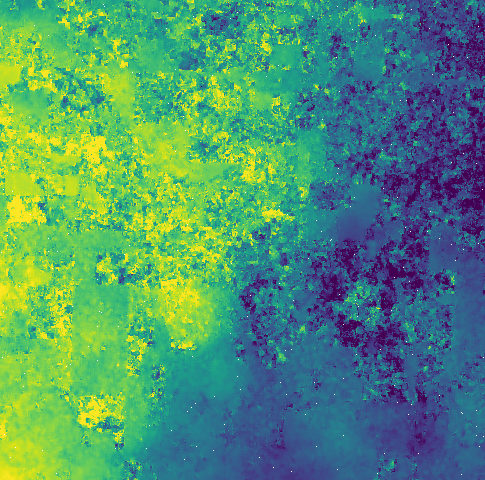

In [19]:
results_list = [file for file in glob.glob(results_path+"/*.nc")]
parts = results_list[-1].split('_')
part1 = parts[-4][:8]
part2 = parts[-3][:8]
data = rxr.open_rasterio(results_list[-1])
disp = data["displacement"].sel(band=1)

coords  = shapefile_gdf.to_crs(epsg='4326').total_bounds
bounds = [[coords[1], coords[0]], [coords[3], coords[2]]]
lat = (coords[1] + coords[3]) / 2
lon = (coords[0] + coords[2]) / 2

disp_values = disp.values.copy()
disp_values = np.nan_to_num(disp_values, nan=np.nan)
vmin, vmax = np.nanpercentile(disp_values, [2, 98])
disp_clipped = np.clip(disp_values, vmin, vmax)
disp_norm = (disp_clipped - vmin) / (vmax - vmin)
cmap = plt.get_cmap('viridis')
disp_rgba = cmap(disp_norm)
disp_rgba[..., 3] = np.where(np.isnan(disp_values), 0, 1)
disp_rgba_img = (disp_rgba * 255).astype(np.uint8)
if disp_rgba_img.ndim == 3 and disp_rgba_img.shape[0] == 4:
    disp_rgba_img = np.transpose(disp_rgba_img, (1, 2, 0))
img = Image.fromarray(disp_rgba_img, mode="RGBA")
img.save(out_dir+"/disp_overlay.png")

m = folium.Map([lat, lon],zoom_start=10,tiles="cartodb positron")
m.add_child(folium.raster_layers.ImageOverlay(image=out_dir+"/disp_overlay.png",bounds=bounds,colormap='viridis',
                                              opacity=1,interactive=True,overlay=True,name='OPERA DISP-S1'))
vmin, vmax = np.nanpercentile(disp_values, [2, 98])
norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(0.6,3),dpi=200)
fig.subplots_adjust(right=0.5)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax)
cbar.set_label("Displacement (m)", fontsize=9)

buf_leg = io.BytesIO()
fig.savefig(buf_leg, format="png", bbox_inches="tight")
plt.close(fig)
url = "data:image/png;base64," + base64.b64encode(buf_leg.getvalue()).decode("utf-8")

legend_html = f"""
<div style="
  position: fixed; bottom: 10px; left: 10px; z-index: 9999;
  background: #fff; border: 1px solid #999; border-radius: 6px;
  padding: 10px 12px; box-shadow: 0 1px 4px rgba(0,0,0,0.3);
  font-size: 12px; line-height: 1.2; pointer-events: none;">

  <!-- centered title -->
  <div style="width:100%; text-align:center; font-weight:700;">OPERA DISP-S1</div>
  <div style="width:100%; text-align:center; margin-bottom:6px;">Displacement (m)</div>

  <!-- colorbar row -->
  <div style="display:flex; align-items:center; gap:8px; justify-content:center;">
    <span style="min-width:42px; text-align:right;">{vmin:.2f}</span>
    <div style="
      height:14px; width:240px; border:1px solid #999; border-radius:3px;
      background: linear-gradient(to right,#440154,#482878,#3e4989,#31688e,#26828e,#1f9e89,#35b779,#6ece58,#b5de2b,#fde725);">
    </div>
    <span style="min-width:42px; text-align:left;">{vmax:.2f}</span>
  </div>
</div>
"""

m.get_root().html.add_child(Element(legend_html))

folium.LayerControl(collapsed=False).add_to(m)
display(m)

In [15]:
m.save(results_path +"/Example_Map.html")

base_name = results_path
format = 'zip'
root_dir = out_dir
base_dir = "./%s"%(results_path.split('/')[-1])
shutil.make_archive(base_name,format,root_dir,base_dir)

'/scratch/11097/shihab_h2i_uta/tapis/b8f68e00-0727-4b37-a8d0-8bb097b77a7d-007/work/cookbooks/cookbook-h2iUTA-jupyter/Tools/SubsidanceProject/OPERA_L3_DISP-S1.zip'